In [331]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate()

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

/Users/ronan/Developer/reeval-multi/mirt-official/load_params.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_data = torch.load(model_path, map_location=torch.dev

--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 19])
Original 'a' matrix shape: torch.Size([78712, 19])

--- After Rotation of 'a' ---
Rotated 'a' matrix shape: (78712, 19)

--- After Transformation of 'theta' ---
Transformed theta shape: (183, 19)

--- Final Standardized Z-Scores (from transformed theta) ---
These are the scores you should use for interpretation.
[[ 1.36679121 -1.29142072  0.02368664 ...  0.5948743   1.20452549
  -1.32143699]
 [ 0.8694796   0.65897874 -2.01923406 ... -0.49557078  1.18055759
  -1.37415132]
 [ 1.82481648 -1.4122685  -0.51204663 ...  0.78741921 -0.97111116
  -1.49879246]
 ...
 [-0.9912067  -0.93205986 -0.40201418 ...  0.99411487 -0.17602767
   1.24166521]
 [-0.71577314 -0.59205097 -0.52410342 ...  1.13348854 -0.10466067
   0.66230223]
 [ 0.18720646 -0.9709694   0.55470963 ...  0.3900838   1.68143397
  -0.28299898]]


# Math score

In [332]:
import numpy as np
import pandas as pd

def compute_scalar_ability(theta_df, a_df, b_series, item_ids, v_unit=None, adjust_difficulty=True):
	"""
	Compute a math-specific ability score from MIRT factors, discriminations, and difficulties.
	
	Args:
		theta_df (pd.DataFrame): Factor scores per test taker (rows = test takers, cols = factors).
		a_df (pd.DataFrame): Discrimination parameters (rows = items, cols = factors).
		b_series (pd.Series): Difficulty parameters (indexed same as a_df rows).
		item_ids (list): List of item IDs (subset of a_df rows) that are math items.
		adjust_difficulty (bool): Whether to weight discriminations by difficulty.
	
	Returns:
		pd.Series: Math ability scores for each test taker.
	"""
	if v_unit is None:
		# 1. Extract discrimination vectors for math items
		A_math = a_df.loc[item_ids].copy()
		b_math = b_series.loc[item_ids]

		# 2. Optionally adjust by difficulty
		if adjust_difficulty:
			weights = 1 / (1 + np.abs(b_math.values))
			A_math = A_math.multiply(weights, axis=0)

		# 3. Compute math direction vector in factor space
		v_unit = A_math.mean(axis=0).values  # vector of length = num_factors
		v_unit = v_unit / np.linalg.norm(v_unit)  # normalize for stability
		print("Mean unit vector: ", v_unit)

	else: 
		print("Used pre-computed math direction vector.", v_unit)

	# 4. Project each test taker's theta onto v_unit
	theta_matrix = theta_df.values  # shape (n_test_takers, n_factors)
	math_scores = theta_matrix.dot(v_unit)

	return pd.Series(math_scores, index=theta_df.index, name="ability")


## PCA analysis

(438, 19)
(19, 19)


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_82213/1173972328.py:97: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


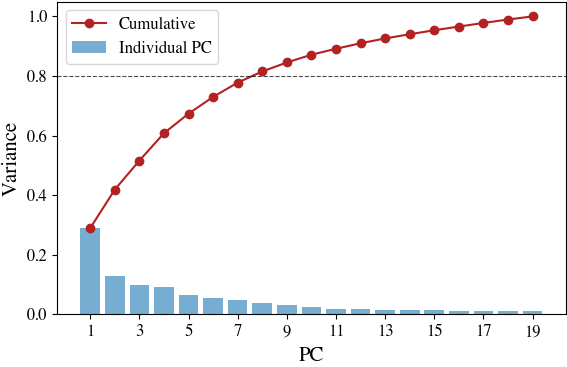

8


In [333]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)


def compute_pca(theta_df, a_df, item_ids, adjust_difficulty=True,
                     return_mean_vector=False, variance_threshold=0.8, b_series=None, save_path='../result/PCA_explained.pdf'):
    """
    Compute math-specific ability dimensions using PCA on discrimination vectors,
    and plot explained variance with threshold.
    
    Args:
        theta_df (pd.DataFrame): Factor scores (models/test-takers x factors)
        a_df (pd.DataFrame): Discrimination parameters (items x factors)
        item_ids (list): List of item IDs considered
        adjust_difficulty (bool): Weight items by difficulty if desired
        return_mean_vector (bool): Also compute the mean-based math vector for comparison
        variance_threshold (float): Cumulative explained variance threshold for selecting PCs
        b_series (pd.Series, optional): Item difficulty for weighting
        
    Returns:
        dict:
            'pca_vectors': numpy array (unit vectors of PCs)
            'pca_loadings': pandas DataFrame of factor loadings per PC
            'mean_vector': numpy array (unit vector of mean, optional)
            'scalar_scores': pd.DataFrame of projected scores for each PC
            'explained_variance': array of variance explained per PC
            'num_pcs_above_threshold': int, number of PCs needed to reach cumulative threshold
    """
    # 1. Extract item discriminations
    A_math = a_df.loc[item_ids].copy()
    
    # 2. Optional: adjust by difficulty
    if adjust_difficulty and b_series is not None:
        b_math = b_series.loc[item_ids]
        weights = 1 / (1 + np.abs(b_math.values))
        A_math = A_math.multiply(weights, axis=0)

    # 3. Fit PCA on all math items
    pca = PCA()
    pca.fit(A_math.values)
    
    pca_vectors = pca.components_  # shape: n_pcs x n_factors
    # Normalize each PC to unit vector
    pca_vectors = np.array([v / np.linalg.norm(v) for v in pca_vectors])
    
    # 4. Compute factor loadings per PC
    # Loading of PC on original factor = eigenvector * sqrt(eigenvalue)
    pca_loadings = pd.DataFrame(
        pca_vectors.T * np.sqrt(pca.explained_variance_),
        index=A_math.columns,
        columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])]
    )
    
    item_loadings = pd.DataFrame(
		A_math.values.dot(pca_vectors.T),
		index=A_math.index,
		columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])]
	)

    print(A_math.values.dot(pca_vectors.T).shape)
    print(pca_vectors.T.shape)
    
    # 5. Optional: compute mean vector for comparison
    v_mean = None
    if return_mean_vector:
        v_mean = A_math.mean(axis=0).values
        v_mean /= np.linalg.norm(v_mean)
    
    # 6. Project theta onto all PCs
    scalar_scores = pd.DataFrame(theta_df.values.dot(pca_vectors.T),
                                 index=theta_df.index,
                                 columns=[f'PC{i+1}' for i in range(pca_vectors.shape[0])])
    
    # 7. Compute cumulative variance and threshold
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    num_pcs_above_threshold = np.searchsorted(cumulative_variance, variance_threshold) + 1
    # 8. Plot explained variance and cumulative variance
    plt.figure(figsize=(6,4))
    plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.6, label='Individual PC')
    plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, color='firebrick', marker='o', label='Cumulative')
    plt.axhline(y=variance_threshold, color='k', linestyle='--', linewidth=0.8, alpha=0.7)
    plt.xticks(range(1, len(explained_variance)+1, 2))
    plt.xlabel('PC')
    plt.ylabel('Variance')
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    
    return {
        'pca_vectors': pca_vectors,
        'pca_loadings': pca_loadings,
        'item_loadings': item_loadings,
        'mean_vector': v_mean,
        'scalar_scores': scalar_scores,
        'explained_variance': explained_variance,
        'num_pcs_above_threshold': num_pcs_above_threshold
    }


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
math_items_mask = resmat.columns.get_level_values('scenario').isin(['math'])

math_questions = resmat.columns[math_items_mask].get_level_values('input.text').to_list()

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

math_items = math_questions

result = compute_pca(theta_df, a_df, math_items, return_mean_vector=True, save_path='../result/PCA_explained_math.pdf')
scalar_scores = result['scalar_scores']
v_pca = result['pca_vectors']
variance = result['explained_variance']
num_pcs = result['num_pcs_above_threshold']
pca_loadings = result['pca_loadings']
item_loadings = result['item_loadings']
print(num_pcs)

In [334]:
math_scores = compute_scalar_ability(theta_df, a_df, b_series, math_items)

conv_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['gsm', 'math'])]].mean(axis=1)
mean_convergent_corr = abs(math_scores.corr(conv_benchmark_scores, method='spearman'))
display(mean_convergent_corr)

div_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['babi_qa', 'imdb'])]].mean(axis=1)
mean_divergent_corr = abs(math_scores.corr(div_benchmark_scores, method='spearman'))
display(mean_divergent_corr)

Mean unit vector:  [-5.51460472e-01 -1.01917039e-01  2.02290804e-02 -1.02911097e-01
 -4.40843191e-02 -2.19111657e-01  8.39204842e-02  6.29863216e-02
 -6.37875854e-01  3.37708140e-02  1.22674996e-01 -4.76612975e-02
  3.87020930e-01 -7.78293942e-02 -2.45902652e-02  4.94843016e-04
 -1.53228290e-01  8.97886884e-02  1.43457422e-02]


np.float64(0.9526152964761807)

np.float64(0.23957658997463038)

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_82213/1057913288.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


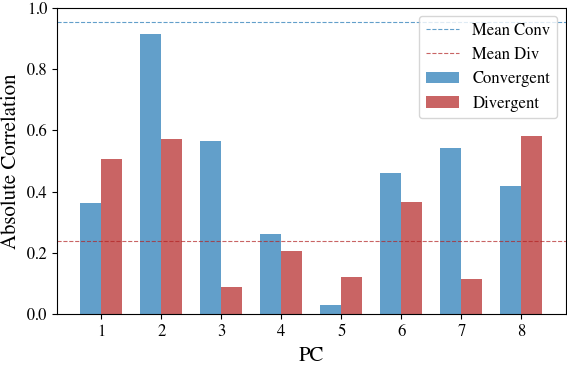

In [335]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlations for PC1, PC2, PC3
pcs = [f'PC{i+1}' for i in range(num_pcs)]
conv_corrs = []
div_corrs = []

for pc in pcs:
    conv_corr = abs(scalar_scores[pc].corr(conv_benchmark_scores, method='spearman'))
    div_corr = abs(scalar_scores[pc].corr(div_benchmark_scores, method='spearman'))
    conv_corrs.append(conv_corr)
    div_corrs.append(div_corr)

# Create the two-bar histogram
x = np.arange(len(pcs))  # PC positions
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, conv_corrs, width, label='Convergent', color='C0', alpha=0.7)
bars2 = ax.bar(x + width/2, div_corrs, width, label='Divergent', color='firebrick', alpha=0.7)


# Add horizontal dashed lines
ax.axhline(y=mean_convergent_corr, color='C0', linestyle='--', alpha=0.7, label='Mean Conv', linewidth=0.8)
ax.axhline(y=mean_divergent_corr, color='firebrick', linestyle='--', alpha=0.7, label='Mean Div', linewidth=0.8)

# Customize the plot
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('PC')
ax.set_xticks(x)
ax.set_xticklabels([f'{i+1}' for i in range(num_pcs)])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig('../result/pc_correlations_histogram_math.pdf')
plt.show()

In [336]:

conv_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['gsm', 'math'])]].mean(axis=1)

# Initialize math_scores with zeros
math_scores = pd.Series(0.0, index=theta_df.index)

math_scores_1 = compute_scalar_ability(theta_df, a_df, b_series, math_items, v_unit=-v_pca[0])
convergent_corr_1 = (math_scores_1.corr(conv_benchmark_scores, method='spearman'))
math_scores_2 = compute_scalar_ability(theta_df, a_df, b_series, math_items, v_unit=-v_pca[1])
convergent_corr_2 = (math_scores_2.corr(conv_benchmark_scores, method='spearman'))
print(f"PC1 convergent correlation: {convergent_corr_1}")
print(f"PC2 convergent correlation: {convergent_corr_2}")
# div_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['babi_qa', 'imdb'])]].mean(axis=1)
# divergent_corr_1 = (math_scores_1.corr(div_benchmark_scores, method='spearman'))
# divergent_corr_2 = (math_scores_2.corr(div_benchmark_scores, method='spearman'))
# print(f"PC1 divergent correlation: {divergent_corr_1}")
# print(f"PC2 divergent correlation: {divergent_corr_2}")

Used pre-computed math direction vector. [-0.95861571  0.02907888  0.03445779 -0.04241917  0.07531008  0.06393744
  0.01077688 -0.01696635  0.06686572 -0.01137414 -0.07347808  0.00362795
 -0.17423796  0.02215022 -0.01097423 -0.00472287 -0.15955795  0.01251761
 -0.02097015]
Used pre-computed math direction vector. [-0.2226236  -0.04699429 -0.01229791 -0.06024247  0.06158671 -0.11965242
  0.07166196  0.04311728 -0.63189004  0.00636141 -0.00652373 -0.05491103
  0.55942595 -0.01306453 -0.03599002  0.00746838  0.44942632  0.01811133
  0.01308707]
PC1 convergent correlation: 0.36348578780011154
PC2 convergent correlation: 0.9148620186432856


In [337]:
math_scores_1.sort_values(ascending=False).head(100)

openai/gpt-3.5-turbo-0613                          1.572702
meta/llama-2-70b                                   1.565648
google/text-unicorn@001                            1.553760
google/gemini-1.0-pro-001                          1.502573
writer/palmyra-x-v3                                1.459808
                                                     ...   
aisingapore/llama3-8b-cpt-sea-lionv2.1-instruct   -0.061109
sail/sailor-7b-chat                               -0.070048
openai/o3-mini-2025-01-31                         -0.096272
deepseek-ai/deepseek-r1                           -0.097233
damo/seallm-7b-v2.5                               -0.120729
Name: ability, Length: 100, dtype: float64

In [338]:
math_scores_1.index.to_list()

['together/t0pp',
 'aisingapore/sea-lion-7b-instruct',
 'eleutherai/pythia-1b-v0',
 'allenai/olmo-7b',
 'together/opt-66b',
 'together/opt-175b',
 'openthaigpt/openthaigpt-1.0.0-7b-chat',
 'openai/code-cushman-001',
 'cohere/large-20220720',
 'together/gpt-neox-20b',
 'cohere/command-light',
 'sambanova/sambalingo-thai-chat',
 'writer/palmyra-x',
 'together/gpt-j-6b',
 'damo/seallm-7b-v2',
 'openthaigpt/openthaigpt-1.0.0-13b-chat',
 'cohere/medium-20220720',
 'cohere/command-medium-beta',
 'openai/curie',
 'mistralai/mixtral-8x7b-instruct-v0.1',
 'sail/sailor-7b-chat',
 'together/ul2',
 'openai/davinci',
 'AlephAlpha/luminous-base',
 'qwen/qwen1.5-7b-chat',
 'scb10x/typhoon-7b',
 'together/redpajama-incite-base-7b',
 'eleutherai/pythia-6.9b',
 'meta/llama-7b',
 'mosaicml/mpt-instruct-30b',
 'mistralai/mixtral-8x22b-instruct-v0.1',
 'openai/o1-mini-2024-09-12',
 'cohere/xlarge-20220609',
 'aisingapore/llama3-8b-cpt-sea-lionv2-base',
 'meta/llama-13b',
 'damo/seallm-7b-v2.5',
 'scb10x/ty

In [339]:
with pd.option_context('display.max_rows', 10):
  common_models = math_scores_1.index.intersection(math_scores_2.index)
  math_cord = pd.DataFrame({
    'PC1': math_scores_1.loc[common_models],
    'PC2': math_scores_2.loc[common_models]
  }, index=common_models)
  display(math_cord.dropna().sort_values(by='PC2', ascending=False).head(100))

,PC1,PC2
meta/llama-3.1-405b-instruct-turbo,0.697150,2.924774
meta/llama-3.2-90b-vision-instruct-turbo,1.217498,2.587932
deepseek-ai/deepseek-v3,0.826964,2.286610
meta/llama-3.1-70b-instruct-turbo,1.036667,2.270019
openai/gpt-4o-2024-08-06,1.083006,2.259337
...,...,...
cohere/command-r,0.399632,-0.034481
google/gemini-1.0-pro-001,1.502573,-0.041456
sambanova/sambalingo-thai-chat,-0.938165,-0.046412
qwen/qwen1.5-7b-chat,-0.191675,-0.057160


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_82213/2905649718.py:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


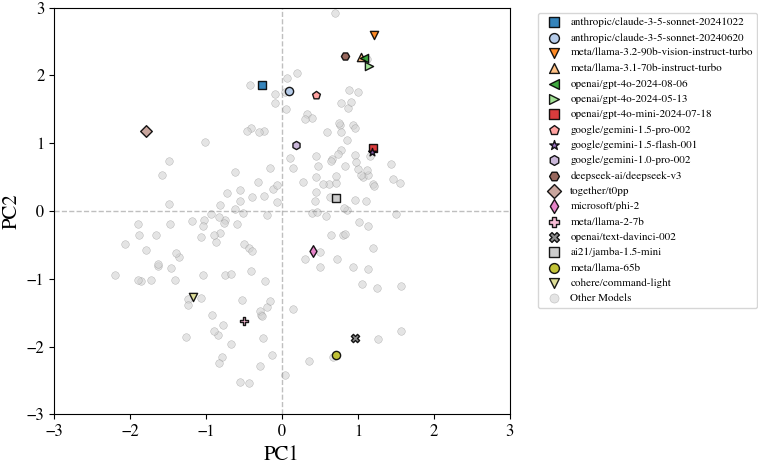

In [340]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get all models
math_mean_full = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].mean(axis=1)
all_indices = math_mean_full.index

# Define top models to highlight (top 15 for cleaner legend)
top_highlighted = ['anthropic/claude-3-5-sonnet-20241022', 'anthropic/claude-3-5-sonnet-20240620',
'meta/llama-3.2-90b-vision-instruct-turbo', 'meta/llama-3.1-70b-instruct-turbo',
'openai/gpt-4o-2024-08-06', 'openai/gpt-4o-2024-05-13', 'openai/gpt-4o-mini-2024-07-18',
'google/gemini-1.5-pro-002', 'google/gemini-1.5-flash-001', 'google/gemini-1.0-pro-002',
'deepseek-ai/deepseek-v3', 'together/t0pp',
'microsoft/phi-2', 'meta/llama-2-7b', 'openai/text-davinci-002', 'ai21/jamba-1.5-mini', 'meta/llama-65b',
'cohere/command-light']

# Get PC1 and PC2 scores for all models
all_pc1 = math_scores_1.loc[all_indices]
all_pc2 = math_scores_2.loc[all_indices]

# Create the plot
plt.figure(figsize=(8, 5))

# First, plot all models as grey dots (Others)
other_indices = [idx for idx in all_indices if idx not in top_highlighted]
other_pc1 = math_scores_1.loc[other_indices]
other_pc2 = math_scores_2.loc[other_indices]

# Define colors and markers for highlighted models
colors = plt.cm.tab20(np.linspace(0, 1, 20))
markers = [
    # Standard shorthand markers
    ',', 'o', 'v', '^', '<', '>', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X',
    ',', 'o', 'v', '^', '<', '>', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X',
]

# Plot highlighted models with unique colors and shapes
highlighted_pc1 = math_scores_1.loc[top_highlighted]
highlighted_pc2 = math_scores_2.loc[top_highlighted]

for i, (model_name, pc1_score, pc2_score) in enumerate(zip(top_highlighted, highlighted_pc1, highlighted_pc2)):
    plt.scatter(pc1_score, pc2_score, 
               color=colors[i], 
               marker=markers[i], 
               s=35, 
               alpha=0.9,
               edgecolors='black',
               linewidth=1,
               label=model_name,
               zorder=3)  # Ensure highlighted points appear on top

plt.scatter(other_pc1, other_pc2, 
           color='lightgray', 
           marker='o', 
           s=30, 
           alpha=0.6,
           edgecolors='gray',
           linewidth=0.3,
           label='Other Models')

# Add quadrant lines
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Customize the plot
plt.xlabel('PC1')
plt.ylabel('PC2')
# plt.grid(True, alpha=0.3)

# Add legend outside the plot area with better formatting
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, 
          ncol=1, frameon=True, fancybox=True, shadow=False,
          markerscale=1.2, handletextpad=0.5)

plt.xlim(-3, 3)
plt.ylim(-3, 3)

plt.tight_layout()
plt.savefig('../result/all_models_algorithmic_vs_abstract.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [341]:
item_loadings.sort_values(by='PC3', ascending=False).head(100).index.to_list()

['A figure skater is facing north when she begins to spin to her right. She spins 2250 degrees. Which direction (north, south, east or west) is she facing when she finishes her spin?',
 'Compute $\\left(\\sqrt{97969}\\right)^2$.',
 'Below is the graph of $y = a \\sin (bx + c)$ for some positive constants $a,$ $b,$ and $c.$  Find $a.$\n\n[asy]import TrigMacros;\n\nsize(300);\n\nreal f(real x)\n{\n\treturn 2*sin(4*x + pi/2);\n}\n\ndraw(graph(f,-pi,pi,n=700,join=operator ..),red);\ntrig_axes(-pi,pi,-3,3,pi/2,1);\nlayer();\nrm_trig_labels(-2,2, 2);\n\nlabel("$1$", (0,1), E);\nlabel("$2$", (0,2), E);\nlabel("$-1$", (0,-1), E);\nlabel("$-2$", (0,-2), E);\n[/asy]',
 'At her track meet, Alice ran at a speed of $9\\ \\text{m/s}$ for $12$ seconds. How many meters did she run?',
 'Below is the graph of $y = a \\cos bx$ for some positive constants $a$ and $b.$  Find $a.$\n\n[asy]import TrigMacros;\n\nsize(400);\n\nreal g(real x)\n{\n\treturn (3*cos(4*x));\n}\n\ndraw(graph(g,-3*pi,3*pi,n=700,join=o

# legalbench

(1997, 19)
(19, 19)


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_82213/1173972328.py:97: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


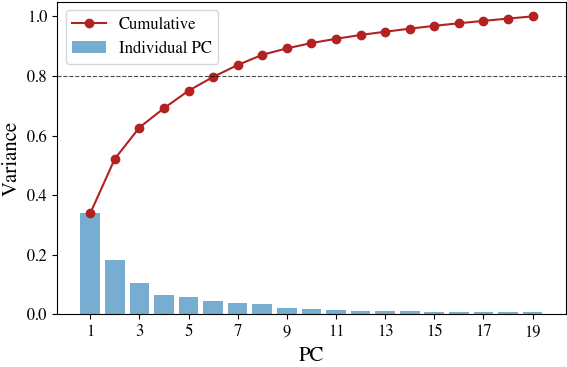

7


In [342]:
conv_dataset = ['legalbench']
div_dataset = ['imdb']


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

result = compute_pca(theta_df, a_df, scenario_questions, return_mean_vector=True, save_path='../result/PCA_explained_legalbench.pdf')
scalar_scores = result['scalar_scores']
v_pca = result['pca_vectors']
variance = result['explained_variance']
num_pcs = result['num_pcs_above_threshold']
pca_loadings = result['pca_loadings']
item_loadings = result['item_loadings']
print(num_pcs)

In [343]:
legalbench_scores = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_pca[0])

conv_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)
mean_convergent_corr = (legalbench_scores.corr(conv_benchmark_scores, method='spearman'))
display(mean_convergent_corr)

div_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(div_dataset)]].mean(axis=1)
mean_divergent_corr = (legalbench_scores.corr(div_benchmark_scores, method='spearman'))
display(mean_divergent_corr)

Used pre-computed math direction vector. [-0.92768031  0.12025617 -0.06288781  0.00289347 -0.16960174  0.07742916
 -0.00347024 -0.02471681  0.03113863 -0.01183727  0.17043147  0.01414482
 -0.02817489  0.03353752 -0.01833773 -0.01058279  0.22367992  0.05157463
 -0.01361087]


np.float64(0.6142238290925349)

np.float64(0.06200049902874555)

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_82213/554017922.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


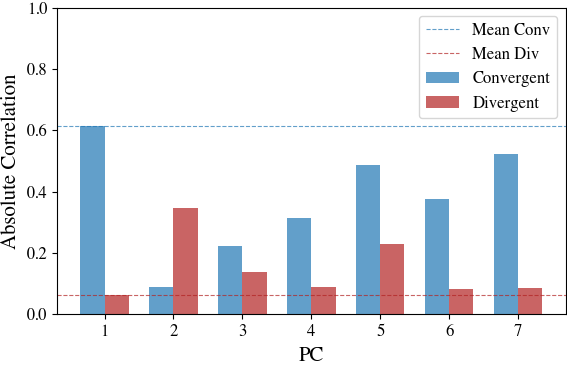

In [344]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlations for PC1, PC2, PC3
pcs = [f'PC{i+1}' for i in range(num_pcs)]
conv_corrs = []
div_corrs = []

for pc in pcs:
    conv_corr = abs(scalar_scores[pc].corr(conv_benchmark_scores, method='spearman'))
    div_corr = abs(scalar_scores[pc].corr(div_benchmark_scores, method='spearman'))
    conv_corrs.append(conv_corr)
    div_corrs.append(div_corr)

# Create the two-bar histogram
x = np.arange(len(pcs))  # PC positions
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, conv_corrs, width, label='Convergent', color='C0', alpha=0.7)
bars2 = ax.bar(x + width/2, div_corrs, width, label='Divergent', color='firebrick', alpha=0.7)


# Add horizontal dashed lines
ax.axhline(y=mean_convergent_corr, color='C0', linestyle='--', alpha=0.7, label='Mean Conv', linewidth=0.8)
ax.axhline(y=mean_divergent_corr, color='firebrick', linestyle='--', alpha=0.7, label='Mean Div', linewidth=0.8)

# Customize the plot
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('PC')
ax.set_xticks(x)
ax.set_xticklabels([f'{i+1}' for i in range(num_pcs)])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig('../result/pc_correlations_histogram_legalbench.pdf')
plt.show()

In [345]:
item_loadings.sort_values(by='PC5', ascending=False).head(100).index.to_list()

['Question: Consider the country of Papua New Guinea. Does the country provide for acquisition of citizenship by the spouse, child or grandchild of a deceased citizen and, if so, under which conditions?',
 'Description: The mark "Seventeen" for magazines targeted at teenagers.',
 'Question: Consider the country of Indonesia. Does the country provide for a child to acquire citizenship based on birth in the territory irrespective of the citizenship and birthplace of his/her parents and, if so, under which conditions?',
 "Statute: The attorney general may bring an action in  for injunctive relief, costs, and attorney's fees and may impose on a manufacturer that violates this section a civil penalty of no more than $10,000.00 per violation. Each unlawful gift shall constitute a separate violation.",
 'Official title of bill: A bill to amend title XI of the Social Security Act to require drug manufacturers to publicly justify unnecessary price increases.\nOfficial summary of bill: Stopping 

# med_qa

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_82213/1173972328.py:97: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


(998, 19)
(19, 19)


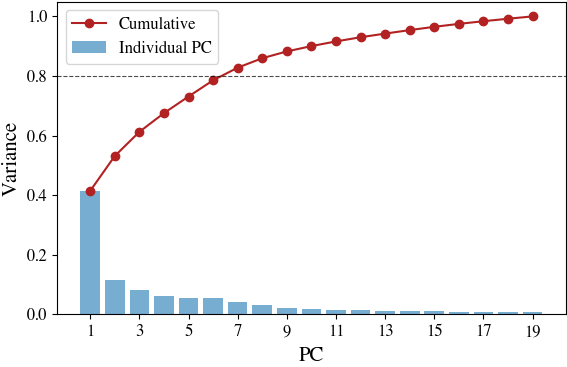

7


In [346]:
conv_dataset = ['med_qa']
div_dataset = ['imdb']


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

result = compute_pca(theta_df, a_df, scenario_questions, return_mean_vector=True, save_path='../result/PCA_explained_med_qa.pdf')
scalar_scores = result['scalar_scores']
v_pca = result['pca_vectors']
variance = result['explained_variance']
num_pcs = result['num_pcs_above_threshold']
pca_loadings = result['pca_loadings']
item_loadings = result['item_loadings']
print(num_pcs)

In [347]:
med_qa_scores = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_pca[1])

conv_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)
mean_convergent_corr = (med_qa_scores.corr(conv_benchmark_scores, method='spearman'))
display(mean_convergent_corr)

div_benchmark_scores = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(div_dataset)]].mean(axis=1)
mean_divergent_corr = (med_qa_scores.corr(div_benchmark_scores, method='spearman'))
display(mean_divergent_corr)

Used pre-computed math direction vector. [-3.47448478e-01 -3.69621224e-02 -1.48975134e-02 -2.08751112e-02
 -1.36136875e-02 -1.40228272e-01 -2.48818753e-02  4.04012899e-02
 -2.26176549e-01  8.49201551e-04  1.79262380e-01 -4.17415142e-02
  4.31278303e-01  1.12418804e-02 -1.92266934e-02 -4.47773701e-04
  7.61975793e-01  5.40350472e-02 -9.84651948e-03]


np.float64(0.8399979298751831)

np.float64(-0.46547268759076876)

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_82213/1162639044.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


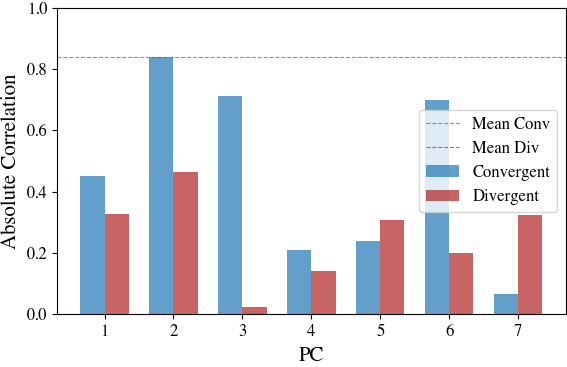

In [348]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate correlations for PC1, PC2, PC3
pcs = [f'PC{i+1}' for i in range(num_pcs)]
conv_corrs = []
div_corrs = []

for pc in pcs:
    conv_corr = abs(scalar_scores[pc].corr(conv_benchmark_scores, method='spearman'))
    div_corr = abs(scalar_scores[pc].corr(div_benchmark_scores, method='spearman'))
    conv_corrs.append(conv_corr)
    div_corrs.append(div_corr)

# Create the two-bar histogram
x = np.arange(len(pcs))  # PC positions
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, conv_corrs, width, label='Convergent', color='C0', alpha=0.7)
bars2 = ax.bar(x + width/2, div_corrs, width, label='Divergent', color='firebrick', alpha=0.7)


# Add horizontal dashed lines
ax.axhline(y=mean_convergent_corr, color='C0', linestyle='--', alpha=0.7, label='Mean Conv', linewidth=0.8)
ax.axhline(y=mean_divergent_corr, color='firebrick', linestyle='--', alpha=0.7, label='Mean Div', linewidth=0.8)

# Customize the plot
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('PC')
ax.set_xticks(x)
ax.set_xticklabels([f'{i+1}' for i in range(num_pcs)])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig('../result/pc_correlations_histogram_med_qa.pdf')
plt.show()

In [349]:
item_loadings.sort_values(by='PC6', ascending=False).head(100).index.to_list()

['A scientist observes a myocyte beating in cell culture. Which step is the most direct necessary component of relaxation for this cell?',
 'A 16-year-old boy is brought to the emergency department by ambulance from a soccer game. During the game, he was about to kick the ball when another player collided with his leg from the front. He was unable to stand up after this collision and reported severe knee pain. On presentation, he was found to have a mild knee effusion. Physical exam showed that his knee could be pushed posteriorly at 90 degrees of flexion but it could not be pulled anteriorly in the same position. The anatomic structure that was most likely injured in this patient has which of the following characteristics?',
 'A 76-year-old man presents to the physician because of dyspepsia and weight loss over the past 6 months. He has no history of any serious illnesses and takes no medications. A diagnostic workup including endoscopy and biopsy shows gastric adenocarcinoma. Before 

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_82213/2934415344.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


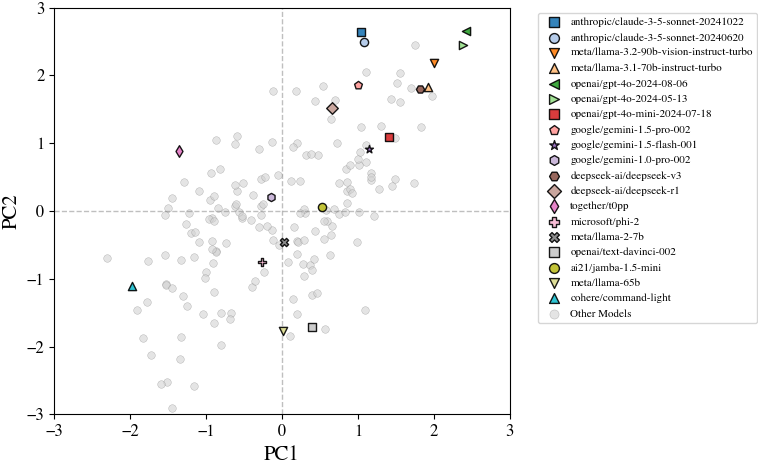

In [350]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get all models
mean_full = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['legalbench', 'med_qa'])]].mean(axis=1)
all_indices = mean_full.index

# Define top models to highlight (top 15 for cleaner legend)
top_highlighted = ['anthropic/claude-3-5-sonnet-20241022', 'anthropic/claude-3-5-sonnet-20240620',
'meta/llama-3.2-90b-vision-instruct-turbo', 'meta/llama-3.1-70b-instruct-turbo',
'openai/gpt-4o-2024-08-06', 'openai/gpt-4o-2024-05-13', 'openai/gpt-4o-mini-2024-07-18',
'google/gemini-1.5-pro-002', 'google/gemini-1.5-flash-001', 'google/gemini-1.0-pro-002',
'deepseek-ai/deepseek-v3', 'deepseek-ai/deepseek-r1', 
'together/t0pp',
'microsoft/phi-2', 'meta/llama-2-7b', 'openai/text-davinci-002', 'ai21/jamba-1.5-mini', 'meta/llama-65b',
'cohere/command-light']

# Get PC1 and PC2 scores for all models
all_pc1 = legalbench_scores.loc[all_indices]
all_pc2 = med_qa_scores.loc[all_indices]

# Create the plot
plt.figure(figsize=(8, 5))

# First, plot all models as grey dots (Others)
other_indices = [idx for idx in all_indices if idx not in top_highlighted]
other_pc1 = legalbench_scores.loc[other_indices]
other_pc2 = med_qa_scores.loc[other_indices]

# Define colors and markers for highlighted models
colors = plt.cm.tab20(np.linspace(0, 1, 20))
markers = [
    # Standard shorthand markers
    ',', 'o', 'v', '^', '<', '>', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X',
    ',', 'o', 'v', '^', '<', '>', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X',
]

# Plot highlighted models with unique colors and shapes
highlighted_pc1 = legalbench_scores.loc[top_highlighted]
highlighted_pc2 = med_qa_scores.loc[top_highlighted]

for i, (model_name, pc1_score, pc2_score) in enumerate(zip(top_highlighted, highlighted_pc1, highlighted_pc2)):
    plt.scatter(pc1_score, pc2_score, 
               color=colors[i], 
               marker=markers[i], 
               s=35, 
               alpha=0.9,
               edgecolors='black',
               linewidth=1,
               label=model_name,
               zorder=3)  # Ensure highlighted points appear on top

plt.scatter(other_pc1, other_pc2, 
           color='lightgray', 
           marker='o', 
           s=30, 
           alpha=0.6,
           edgecolors='gray',
           linewidth=0.3,
           label='Other Models')

# Add quadrant lines
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Customize the plot
plt.xlabel('PC1')
plt.ylabel('PC2')
# plt.grid(True, alpha=0.3)

# Add legend outside the plot area with better formatting
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, 
          ncol=1, frameon=True, fancybox=True, shadow=False,
          markerscale=1.2, handletextpad=0.5)

plt.xlim(-3, 3)
plt.ylim(-3, 3)

plt.tight_layout()
plt.savefig('../result/all_models_scientific_vs_logical.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [351]:
resmat.columns.get_level_values('scenario').unique().tolist()

['lsat_qa',
 'truthful_qa',
 'synthetic_reasoning',
 'babi_qa',
 'wikifact',
 'bbq',
 'thai_exam',
 'dyck_language_np=3',
 'legal_support',
 'civil_comments',
 'legalbench',
 'raft',
 'air_bench_2024',
 'math',
 'med_qa',
 'gsm',
 'boolq',
 'mmlu',
 'entity_matching',
 'entity_data_imputation',
 'commonsense',
 'imdb']

In [352]:
# Get mean scores and find common indices (models that have non-NaN values for both)
mean_other = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['legalbench', 'med_qa'])]].dropna().mean(axis=1)
mean_math = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].dropna().mean(axis=1)
common_indices = list(set(mean_other.index.to_list()).intersection(set(mean_math.index.to_list())))
common_indices

['qwen/qwen2-72b-instruct',
 'qwen/qwen2.5-72b-instruct-turbo',
 'openai/gpt-4-0613',
 'meta/llama-3.2-11b-vision-instruct-turbo',
 'mistralai/mixtral-8x7b-32kseqlen',
 'meta/llama-3.2-90b-vision-instruct-turbo',
 'deepseek-ai/deepseek-v3',
 'google/gemini-1.5-flash-001',
 'meta/llama-3-8b',
 'anthropic/claude-3-5-sonnet-20241022',
 'openai/gpt-4-1106-preview',
 'anthropic/claude-2.1',
 'microsoft/phi-3-medium-4k-instruct',
 'google/gemini-1.5-flash-002',
 'qwen/qwen2.5-7b-instruct-turbo',
 'amazon/nova-pro-v1:0',
 'qwen/qwen1.5-32b',
 'openai/gpt-4-turbo-2024-04-09',
 'google/gemini-1.0-pro-002',
 'cohere/command',
 'anthropic/claude-3-opus-20240229',
 'ai21/j2-grande',
 'anthropic/claude-3-haiku-20240307',
 'cohere/command-r',
 'google/text-unicorn@001',
 'AlephAlpha/luminous-supreme',
 'mistralai/mistral-7b-v0.1',
 'amazon/nova-micro-v1:0',
 'openai/gpt-4o-mini-2024-07-18',
 'openai/gpt-4o-2024-08-06',
 'ai21/jamba-1.5-mini',
 'google/gemini-1.5-pro-001',
 'google/gemini-1.5-pro-002

In [353]:
# Get mean scores and find common indices (models that have non-NaN values for both)
mean_other = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['legalbench', 'med_qa'])]].dropna()
mean_math = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].dropna()
common_indices = list(set(mean_other.index.to_list()).intersection(set(mean_math.index.to_list())))

top_highlighted = [
    # 01.AI
    "01-ai/yi-34b",
    "01-ai/yi-large-preview",

    # AI21
    "ai21/jamba-1.5-large",

    # Anthropic (Claude series for progression)
    "anthropic/claude-2.1",
    "anthropic/claude-3-opus-20240229",
    "anthropic/claude-3-5-sonnet-20241022",

    # DeepSeek
    "deepseek-ai/deepseek-v3",

    # Google (Gemini & Gemma)
    "google/gemini-1.5-pro-002",
    "google/gemini-2.0-flash-exp",

    # Meta (LLaMA iterations, including the massive 405B)
    "meta/llama-3.1-405b-instruct-turbo",
    "meta/llama-3.2-90b-vision-instruct-turbo",
    "meta/llama-3.3-70b-instruct-turbo",

    # Mistral (Large + MoE)
    "mistralai/mixtral-8x22b",
    "mistralai/mistral-large-2407",

    # OpenAI (GPT-4/4o evolution)
    "openai/gpt-4-1106-preview",
    "openai/gpt-4o-2024-05-13",
    "openai/gpt-4o-2024-08-06",

    # Qwen (latest large release)
    "qwen/qwen2.5-72b-instruct-turbo",

    "amazon/nova-pro-v1:0",

    "microsoft/phi-3-medium-4k-instruct",

    "cohere/command-r-plus"
]


# Filter to only include models that exist in common_indices
models_to_highlight = [m for m in top_highlighted if m in common_indices]
print(f"Highlighting {len(models_to_highlight)} models out of {len(top_highlighted)} candidates")
# Create mapping from full model names to display names

model_display_names = {
    # 01.AI
    "01-ai/yi-34b": "Yi 34B",
    "01-ai/yi-large-preview": "Yi Large Preview",

    # AI21
    "ai21/jamba-1.5-large": "Jamba 1.5 Large",

    # Anthropic (Claude family)
    "anthropic/claude-2.1": "Claude 2.1",
    "anthropic/claude-3-opus-20240229": "Claude 3 Opus (Feb 24)",
    "anthropic/claude-3-5-sonnet-20241022": "Claude 3.5 Sonnet (Oct 24)",

    # DeepSeek
    "deepseek-ai/deepseek-v3": "DeepSeek V3",

    # Google
    "google/gemini-1.5-pro-002": "Gemini 1.5 Pro",
    "google/gemini-2.0-flash-exp": "Gemini 2.0 Flash Exp",

    # Meta (LLaMA family)
    "meta/llama-3.1-405b-instruct-turbo": "Llama 3.1 405B",
    "meta/llama-3.2-90b-vision-instruct-turbo": "Llama 3.2 90B Vision",
    "meta/llama-3.3-70b-instruct-turbo": "Llama 3.3 70B",

    # Mistral
    "mistralai/mixtral-8x22b": "Mixtral 8x22B",
    "mistralai/mistral-large-2407": "Mistral Large (Jul 24)",

    # OpenAI (GPT-4/4o lineage)
    "openai/gpt-4-1106-preview": "GPT-4 (Nov 23 Preview)",
    "openai/gpt-4o-2024-05-13": "GPT-4o (May 24)",
    "openai/gpt-4o-2024-08-06": "GPT-4o (Aug 24)",

    # Qwen
    "qwen/qwen2.5-72b-instruct-turbo": "Qwen2.5 72B Turbo",

    # Amazon
    "amazon/nova-pro-v1:0": "Nova Pro v1",

    # Microsoft
    "microsoft/phi-3-medium-4k-instruct": "Phi-3 Medium 4K",

    # Cohere
    "cohere/command-r-plus": "Command R+",
}


# Create company groupings and assign markers
company_markers = {
    'anthropic': 'o',
    'meta': 's',
    'openai': '^',
    'google': 'P',
    'deepseek-ai': 'v',
    'together': 'p',
    'microsoft': 'd',
    'ai21': 'h',
    'cohere': 'X',
    '01-ai': '*',
    'amazon': '<',
}

Highlighting 21 models out of 21 candidates


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_82213/2855862883.py:95: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


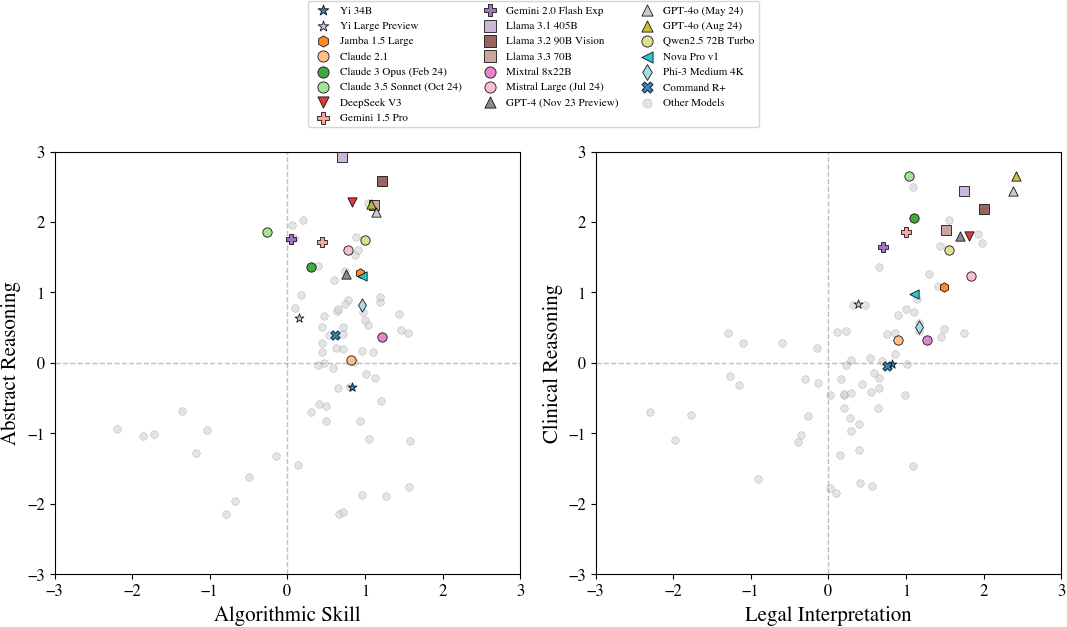

In [354]:
import matplotlib.pyplot as plt
import numpy as np

# Create color palette and assign colors/markers to filtered models
all_colors = plt.cm.tab20(np.linspace(0, 1, 20))
model_colors = {}
model_markers = {}

for i, model in enumerate(models_to_highlight):
    company = model.split('/')[0]
    model_markers[model] = company_markers.get(company, 'o')
    model_colors[model] = all_colors[i % len(all_colors)]

# Create composite figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6))

# Identify other models (not highlighted)
other_indices = [idx for idx in common_indices if idx not in models_to_highlight]

# SUBPLOT 1: Math skills (Algorithmic vs Abstract Reasoning)
# Plot other models as grey dots
other_pc1_math = math_scores_1.loc[other_indices]
other_pc2_math = math_scores_2.loc[other_indices]

# Plot highlighted models
for model_name in models_to_highlight:
    pc1_score = math_scores_1.loc[model_name]
    pc2_score = math_scores_2.loc[model_name]
    ax1.scatter(pc1_score, pc2_score, 
               color=model_colors[model_name], 
               marker=model_markers[model_name], 
               s=45, 
               alpha=0.9,
               edgecolors='black',
               linewidth=0.6,
               label=model_display_names.get(model_name, model_name),
               zorder=3)

ax1.scatter(other_pc1_math, other_pc2_math, 
           color='lightgray', 
           marker='o', 
           s=30, 
           alpha=0.6,
           edgecolors='gray',
           linewidth=0.3,
           label='Other Models')

# Add quadrant lines and customize
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.set_xlabel('Algorithmic Skill')
ax1.set_ylabel('Abstract Reasoning')
ax1.set_xlim(-3, 3)
ax1.set_ylim(-3, 3)

# SUBPLOT 2: Common skills (Precedent vs Structural Reasoning)
# Plot other models as grey dots
other_pc1_common = legalbench_scores.loc[other_indices]
other_pc2_common = med_qa_scores.loc[other_indices]

# Plot highlighted models (same models, colors, and markers as subplot 1)
for model_name in models_to_highlight:
    pc1_score = legalbench_scores.loc[model_name]
    pc2_score = med_qa_scores.loc[model_name]
    ax2.scatter(pc1_score, pc2_score, 
               color=model_colors[model_name], 
               marker=model_markers[model_name], 
               s=45, 
               alpha=0.9,
               edgecolors='black',
               linewidth=0.6,
               zorder=3)  # No label to avoid duplicate

ax2.scatter(other_pc1_common, other_pc2_common, 
           color='lightgray', 
           marker='o', 
           s=30, 
           alpha=0.6,
           edgecolors='gray',
           linewidth=0.3)  # No label to avoid duplicate

# Add quadrant lines and customize
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax2.set_xlabel('Legal Interpretation')
ax2.set_ylabel('Clinical Reasoning')
ax2.set_xlim(-3, 3)
ax2.set_ylim(-3, 3)

# Add shared legend (only from first subplot to avoid duplicates)
fig.legend(bbox_to_anchor=(0.5, 1.08), loc='upper center', fontsize=8, 
          ncol=3, frameon=True, fancybox=True, shadow=False,
          markerscale=1.2, handletextpad=0.5, columnspacing=1.5)

plt.tight_layout()
plt.subplots_adjust(top=0.82)  # Create more space at top for legend
plt.savefig('../result/model_comparison_combined_skills.pdf', bbox_inches='tight', dpi=300)
plt.show()
